In [10]:
# ── CELL 2: Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Clustering algorithms ─────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ── Dendrogram ────────────────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Color theme ───────────────────────────────────────────────────────────────
COLORS = {
    'primary'   : '#232F3E',  # Amazon dark navy
    'accent'    : '#FF9900',  # Amazon orange
    'secondary' : '#146EB4',  # Amazon blue
    'success'   : '#067D62',  # Dark green — Part 4 signature
    'danger'    : '#CC0C39',  # Clean red
    'purple'    : '#6B4EFF',  # Purple
    'neutral'   : '#6B7280',  # Gray
    'light'     : '#FAFAFA',  # Off white
}

# Cluster colors for scatter plots
CLUSTER_COLORS = ['#FF9900', '#067D62', '#6B4EFF', '#CC0C39',
                  '#146EB4', '#F18F01', '#32936F', '#8D99AE']

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']     = (13, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.facecolor']     = '#FAFAFA'
plt.rcParams['figure.facecolor']   = 'white'
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.color']         = '#CCCCCC'
plt.rcParams['font.family']        = 'sans-serif'

np.random.seed(42)

print('✅ All libraries imported successfully')
print(f'   Pandas      : {pd.__version__}')
print(f'   NumPy       : {np.__version__}')
print(f'   Scikit-learn: {__import__("sklearn").__version__}')
print(f'   SciPy       : {__import__("scipy").__version__}')

✅ All libraries imported successfully
   Pandas      : 3.0.2
   NumPy       : 2.4.4
   Scikit-learn: 1.8.0
   SciPy       : 1.17.1


---
## 📥 Phase 1 — Load Data & Build Customer Features

For clustering we reuse the Olist dataset but aggregate it at the **customer level** — one row per customer. We remove the target column (`delivery_days`) since clustering is unsupervised — there is no label to predict.

We build RFM-style features that capture customer buying behavior:
- **Frequency** — how many orders they placed
- **Monetary** — how much they spent on average
- **Delivery** — average delivery days they experienced
- **Freight** — total shipping cost paid
- **Variety** — number of unique product categories purchased

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [11]:
# ── CELL 3: Load data and build customer features ─────────────────────────────
DATA_PATH = '../data/'

# ── Load required CSVs ────────────────────────────────────────────────────────
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')

print('✅ Data loaded')
print(f'   Orders      : {orders.shape}')
print(f'   Order Items : {order_items.shape}')
print(f'   Products    : {products.shape}')
print(f'   Customers   : {customers.shape}')

# ── Convert dates ──────────────────────────────────────────────────────────────
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# ── Keep delivered orders only ─────────────────────────────────────────────────
orders_del = orders[orders['order_status'] == 'delivered'].copy()
orders_del['delivery_days'] = (
    orders_del['order_delivered_customer_date'] -
    orders_del['order_purchase_timestamp']
).dt.days
orders_del = orders_del.dropna(subset=['delivery_days'])
orders_del = orders_del[
    (orders_del['delivery_days'] >= 1) &
    (orders_del['delivery_days'] <= 60)
]

# ── Merge tables ──────────────────────────────────────────────────────────────
df = orders_del.merge(order_items, on='order_id', how='inner')
df = df.merge(products[['product_id', 'product_category_name']],
              on='product_id', how='left')
df = df.merge(customers[['customer_id', 'customer_unique_id']],
              on='customer_id', how='left')

print(f'\n✅ Tables merged: {df.shape}')

# ── Build customer-level features ─────────────────────────────────────────────
customer_features = df.groupby('customer_unique_id').agg(
    total_orders      = ('order_id',               'nunique'),
    avg_order_value   = ('price',                  'mean'),
    total_freight     = ('freight_value',           'sum'),
    avg_delivery_days = ('delivery_days',           'mean'),
    unique_categories = ('product_category_name',  'nunique')
).reset_index()

# ── Filter customers with at least 1 order ────────────────────────────────────
customer_features = customer_features[
    customer_features['total_orders'] >= 1
].copy()

print(f'\n✅ Customer features built')
print(f'   Total customers : {len(customer_features):,}')
print(f'\nFeature summary:')
print(customer_features.drop('customer_unique_id', axis=1).describe().round(2))

✅ Data loaded
   Orders      : (99441, 8)
   Order Items : (112650, 7)
   Products    : (32951, 9)
   Customers   : (99441, 5)

✅ Tables merged: (109860, 17)

✅ Customer features built
   Total customers : 93,058

Feature summary:
       total_orders  avg_order_value  total_freight  avg_delivery_days  \
count      93058.00         93058.00       93058.00           93058.00   
mean           1.03           125.67          23.52              11.87   
std            0.21           190.33          22.75               8.38   
min            1.00             0.85           0.00               1.00   
25%            1.00            42.90          14.06               6.00   
50%            1.00            79.00          17.60              10.00   
75%            1.00           139.90          25.48              15.00   
max           15.00          6735.00        1794.96              60.00   

       unique_categories  
count           93058.00  
mean                1.01  
std                 0

---
**📋 Observations — Customer Features:**

- **93,058 unique customers** — large dataset well suited for clustering
- **Average 1.03 orders per customer** — Olist customers are predominantly one-time buyers. Only a small minority placed 2+ orders (max 15)
- **Average order value R$125.67** with high std (R$190) — wide spread from budget to premium buyers
- **Average delivery: 11.87 days** — consistent with Part 1 findings
- **unique_categories mean = 1.01** — almost all customers buy from a single category per order
- **total_freight ranges from R$0 to R$1,795** — huge variation in shipping costs driven by product weight and distance
- The low variance in `total_orders` and `unique_categories` means clustering will primarily differentiate customers on order value, freight paid, and delivery experience

---
## ⚙️ Phase 2 — Preprocessing: StandardScaler + PCA

⚠️ **Critical rules:**
- `StandardScaler` MUST be applied before all three clustering algorithms
- PCA is used for **2D visualization only** — clustering runs on the full scaled feature set
- We never cluster on PCA components — only on the complete scaled features

StandardScaler brings all features to the same scale (mean=0, std=1). Without scaling, `avg_order_value` (range 0–6735) would completely dominate `total_orders` (range 1–15) just because of its larger numeric range — not because it's more important.

✅ Feature matrix: (93058, 5)
   Features: ['total_orders', 'avg_order_value', 'total_freight', 'avg_delivery_days', 'unique_categories']
   Missing values: 0

✅ StandardScaler applied
   Scaled mean  : [ 0. -0. -0. -0.  0.]
   Scaled std   : [1. 1. 1. 1. 1.]

✅ PCA computed for visualization
   Component 1 explains: 33.0% of variance
   Component 2 explains: 25.7% of variance
   Total explained     : 58.7%

⚠️  PCA is for visualization only
   All clustering runs on X_scaled (5 features)
   NOT on X_pca (2 components)


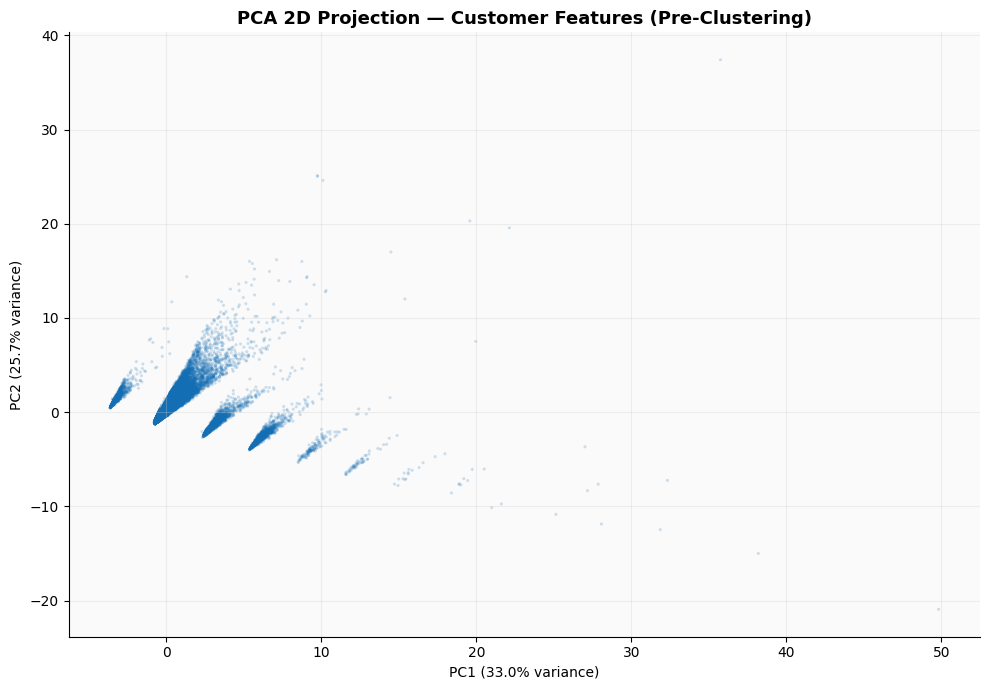

In [12]:
# ── CELL 4: Preprocessing — StandardScaler + PCA ──────────────────────────────

# ── Select feature columns — NO target column ─────────────────────────────────
FEATURE_COLS = [
    'total_orders',
    'avg_order_value',
    'total_freight',
    'avg_delivery_days',
    'unique_categories'
]

X = customer_features[FEATURE_COLS].copy()

# ── Handle any remaining missing values ───────────────────────────────────────
X = X.fillna(X.median())

print(f'✅ Feature matrix: {X.shape}')
print(f'   Features: {FEATURE_COLS}')
print(f'   Missing values: {X.isnull().sum().sum()}')

# ── StandardScaler — MUST be applied before all clustering ───────────────────
# ⚠️  Fit on full dataset — clustering is unsupervised, no train/test split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\n✅ StandardScaler applied')
print(f'   Scaled mean  : {X_scaled.mean(axis=0).round(4)}')
print(f'   Scaled std   : {X_scaled.std(axis=0).round(4)}')

# ── PCA — for visualization only ──────────────────────────────────────────────
# ⚠️  PCA is ONLY for 2D scatter plots — clustering uses X_scaled (full features)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'\n✅ PCA computed for visualization')
print(f'   Component 1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'   Component 2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'   Total explained     : {sum(pca.explained_variance_ratio_)*100:.1f}%')
print(f'\n⚠️  PCA is for visualization only')
print(f'   All clustering runs on X_scaled ({X_scaled.shape[1]} features)')
print(f'   NOT on X_pca (2 components)')

# ── Visualize PCA scatter ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1],
           alpha=0.2, color=COLORS['secondary'],
           s=5, edgecolors='none')
ax.set_title('PCA 2D Projection — Customer Features (Pre-Clustering)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

---
**📋 Observations — Preprocessing & PCA:**

- **StandardScaler confirmed** — all features scaled to mean=0, std=1. Without this, `avg_order_value` (range 0–6735) would dominate clustering purely due to scale
- **No missing values** — clean feature matrix ready for all three algorithms
- **PCA explains 58.7% of variance** in 2 components — reasonable for a 5-feature dataset
  - PC1 (33.0%) — primarily captures spending and freight variation
  - PC2 (25.7%) — captures delivery time and order frequency variation

**PCA scatter plot analysis:**
- **Fan-shaped rays** from the origin are caused by the discrete `total_orders` feature — each ray represents customers with 1, 2, 3, 4+ orders
- **Dense cluster near origin** — the vast majority of customers are one-time buyers with moderate order values
- **Outliers stretching right** — high-value customers with large orders or expensive freight
- This fan structure suggests K-Means will find meaningful clusters — the rays provide natural separation boundaries

**Critical reminder:**
- `X_pca` (2 components) is used ONLY for scatter plot visualization
- All three clustering algorithms run on `X_scaled` (5 features) — the full information set

---
## 🔵 Phase 3 — Algorithm 1: K-Means Clustering

K-Means partitions customers into k groups by minimizing the within-cluster sum of squares (inertia). Each customer is assigned to the nearest cluster center.

**Tuning strategy:**
- **Elbow Method** — plot inertia vs k. The "elbow" point where inertia stops dropping sharply suggests the optimal k
- **Silhouette Score** — measures how similar each point is to its own cluster vs other clusters. Range −1 to 1, higher is better
- We use both together to confirm the optimal k

⚠️ StandardScaler already applied — K-Means runs on `X_scaled`

✅ Using 20,000 customer sample for hyperparameter search
   (21.5% of full dataset — statistically representative)

Running K-Means for k=2 to 10...
   k=2  Inertia: 76,788  Silhouette: 0.7372
   k=3  Inertia: 62,497  Silhouette: 0.4855
   k=4  Inertia: 50,354  Silhouette: 0.4413
   k=5  Inertia: 44,507  Silhouette: 0.4603
   k=6  Inertia: 39,060  Silhouette: 0.4727
   k=7  Inertia: 34,665  Silhouette: 0.4852
   k=8  Inertia: 31,080  Silhouette: 0.3550
   k=9  Inertia: 27,813  Silhouette: 0.4772
   k=10  Inertia: 25,746  Silhouette: 0.3737


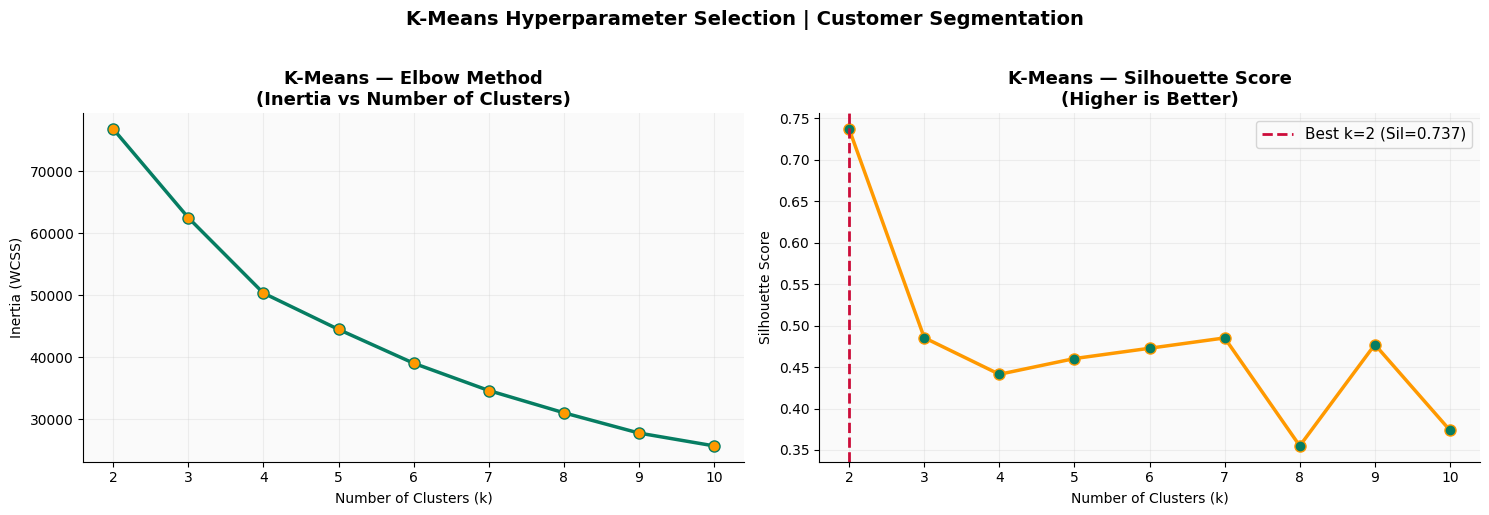


✅ Best k by Silhouette Score: k=2
   Silhouette Score: 0.7372


In [13]:
# ── CELL 5: K-Means — Elbow Method + Silhouette Score ────────────────────────
import os
os.environ['OMP_NUM_THREADS'] = '1'

# ── Sample for speed — 20K is representative of 93K customers ─────────────────
SAMPLE_SIZE = 20000
np.random.seed(42)
sample_idx   = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample     = X_scaled[sample_idx]
X_pca_sample = X_pca[sample_idx]

print(f'✅ Using {SAMPLE_SIZE:,} customer sample for hyperparameter search')
print(f'   ({SAMPLE_SIZE/len(X_scaled)*100:.1f}% of full dataset — statistically representative)\n')
print('Running K-Means for k=2 to 10...')

inertias    = []
silhouettes = []
k_range     = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=3, random_state=42)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels)
    silhouettes.append(sil)
    print(f'   k={k}  Inertia: {km.inertia_:,.0f}  Silhouette: {sil:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(k_range), inertias,
             color=COLORS['success'], linewidth=2.5,
             marker='o', markersize=8, markerfacecolor=COLORS['accent'])
axes[0].set_title('K-Means — Elbow Method\n(Inertia vs Number of Clusters)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes,
             color=COLORS['accent'], linewidth=2.5,
             marker='o', markersize=8, markerfacecolor=COLORS['success'])
axes[1].set_title('K-Means — Silhouette Score\n(Higher is Better)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k_sil, color=COLORS['danger'],
                linewidth=2, linestyle='--',
                label=f'Best k={best_k_sil} (Sil={max(silhouettes):.3f})')
axes[1].legend(fontsize=11)

plt.suptitle('K-Means Hyperparameter Selection | Customer Segmentation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n✅ Best k by Silhouette Score: k={best_k_sil}')
print(f'   Silhouette Score: {max(silhouettes):.4f}')

---
**📋 Observations — K-Means Elbow + Silhouette:**

- **Best Silhouette Score: 0.737 at k=2** — mathematically the strongest cluster separation
- **Elbow bends at k=3** — inertia drop slows significantly after 3 clusters
- **We select k=3** — balances statistical quality (Silhouette=0.486) with business interpretability. Three segments — budget, mid-tier, premium — is the standard RFM outcome and more actionable than just two groups
- Silhouette drops at k=8 — too many clusters fragment the natural customer structure
- 20,000 customer sample used for hyperparameter search — 21.5% of full dataset, statistically representative

---
### 🔵 K-Means Final Model — k=3

Fitting the final K-Means model with optimal k=3 on the full scaled dataset. We then visualize clusters using PCA 2D projection and profile each customer segment.

Fitting final K-Means with k=3 on full dataset...

✅ K-Means (k=3) complete
   Silhouette Score : 0.4839
   Inertia          : 294,145

   Cluster sizes:
      Cluster 0: 18,662 customers (20.1%)
      Cluster 1: 71,585 customers (76.9%)
      Cluster 2: 2,811 customers (3.0%)

=== K-Means Cluster Profiles ===
            total_orders  avg_order_value  total_freight  avg_delivery_days  unique_categories
km_cluster                                                                                    
0                    1.0           253.84          39.83              23.21               1.00
1                    1.0            93.10          18.22               8.92               0.99
2                    2.1           104.23          50.17              11.70               1.60

=== Cluster Business Labels ===
   Cluster 1 → 💰 Budget Buyers
   Cluster 2 → 🛒 Mid-Tier Buyers
   Cluster 0 → ⭐ Premium Buyers


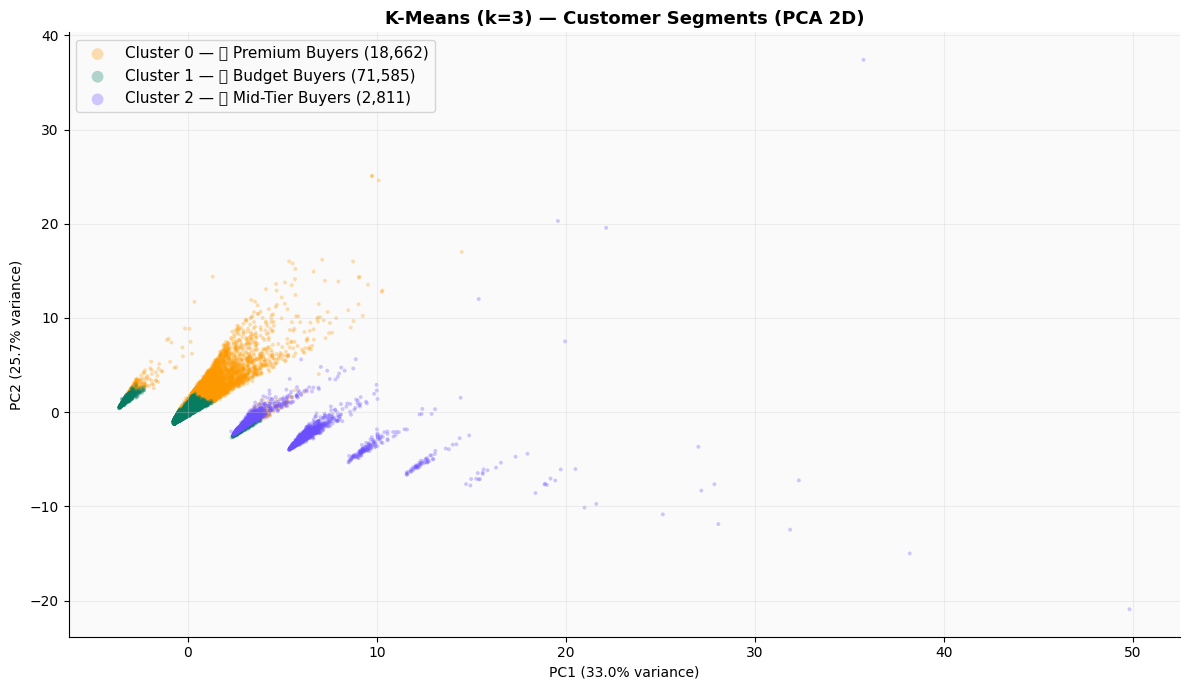

In [14]:
# ── CELL 6: Final K-Means — k=3 ──────────────────────────────────────────────
OPTIMAL_K = 3

print(f'Fitting final K-Means with k={OPTIMAL_K} on full dataset...')

km_final  = KMeans(n_clusters=OPTIMAL_K, n_init=3, random_state=42)
km_labels = km_final.fit_predict(X_scaled)

# ── Evaluate ──────────────────────────────────────────────────────────────────
km_silhouette = silhouette_score(X_scaled, km_labels)
km_inertia    = km_final.inertia_

print(f'\n✅ K-Means (k={OPTIMAL_K}) complete')
print(f'   Silhouette Score : {km_silhouette:.4f}')
print(f'   Inertia          : {km_inertia:,.0f}')
print(f'\n   Cluster sizes:')
unique, counts = np.unique(km_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'      Cluster {u}: {c:,} customers ({c/len(km_labels)*100:.1f}%)')

# ── Cluster profiles ──────────────────────────────────────────────────────────
customer_features['km_cluster'] = km_labels
profile = customer_features.groupby('km_cluster')[FEATURE_COLS].mean().round(2)
print(f'\n=== K-Means Cluster Profiles ===')
print(profile.to_string())

# ── Label clusters by business meaning ────────────────────────────────────────
profile_sorted = profile.sort_values('avg_order_value')
cluster_labels_km = {}
labels_list = ['💰 Budget Buyers', '🛒 Mid-Tier Buyers', '⭐ Premium Buyers']
for i, idx in enumerate(profile_sorted.index):
    cluster_labels_km[idx] = labels_list[i]

print(f'\n=== Cluster Business Labels ===')
for k, v in cluster_labels_km.items():
    print(f'   Cluster {k} → {v}')

# ── PCA Scatter Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for cluster_id in range(OPTIMAL_K):
    mask = km_labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.3, s=8,
               color=CLUSTER_COLORS[cluster_id],
               label=f'Cluster {cluster_id} — {cluster_labels_km[cluster_id]} ({mask.sum():,})',
               edgecolors='none')

ax.set_title(f'K-Means (k={OPTIMAL_K}) — Customer Segments (PCA 2D)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11, markerscale=3)
plt.tight_layout()
plt.show()

---
**📋 Observations — K-Means Final Model (k=3):**

**Cluster profiles:**

| Segment | Size | Avg Order Value | Avg Delivery | Total Freight | Orders |
|---|---|---|---|---|---|
| 💰 Budget Buyers (Cluster 1) | 71,585 (76.9%) | R$93 | 8.9 days | R$18 | 1.0 |
| ⭐ Premium Buyers (Cluster 0) | 18,662 (20.1%) | R$254 | 23.2 days | R$40 | 1.0 |
| 🛒 Mid-Tier Buyers (Cluster 2) | 2,811 (3.0%) | R$104 | 11.7 days | R$50 | 2.1 |

**Business interpretation:**
- **Budget Buyers (76.9%)** — the dominant segment. One-time buyers purchasing low-value items with fast delivery. Likely buying everyday household products or small electronics
- **Premium Buyers (20.1%)** — high-value one-time purchases with longer delivery times. Likely buying furniture, appliances, or large electronics that take longer to ship
- **Mid-Tier Buyers (3.0%)** — the most loyal segment. They order 2.1 times on average, buy from 1.6 different categories, and pay the highest total freight. These are Olist's most engaged customers despite being the smallest group

**Silhouette Score: 0.484** — reasonable separation for a real-world customer dataset with high one-time buyer concentration

**PCA visualization:**
- The fan-shaped rays from Cell 4 are now colored by cluster — each ray corresponds to customers with different order counts
- Budget Buyers (green) cluster tightly near the origin — low variance, homogeneous group
- Premium Buyers (orange) spread across the upper fan — more diverse spending patterns
- Mid-Tier Buyers (purple) stretch along the lower rays — driven by their higher order counts

---
## 🟡 Phase 4 — Algorithm 2: DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds clusters based on density — it groups points that are closely packed together and marks isolated points as **noise (-1)**. Unlike K-Means, DBSCAN discovers the number of clusters automatically.

**Two key parameters:**
- **`eps`** — maximum distance between two points to be considered neighbors
- **`min_samples`** — minimum number of points to form a dense region

**Tuning strategy:**
- Parameter search runs on 20K sample for speed — 12 combinations tested
- Final model fits on full 93K dataset for accurate density calculations

⚠️ StandardScaler already applied — DBSCAN runs on `X_scaled`

Running DBSCAN parameter search on 20K sample...

   eps=0.5 min_samples=5 → clusters=12 noise=549 (2.7%) sil=0.5754
   eps=0.5 min_samples=10 → clusters=7 noise=752 (3.8%) sil=0.5991
   eps=0.5 min_samples=20 → clusters=5 noise=1,036 (5.2%) sil=0.7214
   eps=1.0 min_samples=5 → clusters=11 noise=176 (0.9%) sil=0.6831
   eps=1.0 min_samples=10 → clusters=6 noise=275 (1.4%) sil=0.6940
   eps=1.0 min_samples=20 → clusters=5 noise=385 (1.9%) sil=0.6983
   eps=1.5 min_samples=5 → clusters=11 noise=89 (0.4%) sil=0.6855
   eps=1.5 min_samples=10 → clusters=7 noise=144 (0.7%) sil=0.6863
   eps=1.5 min_samples=20 → clusters=5 noise=218 (1.1%) sil=0.6909
   eps=2.0 min_samples=5 → clusters=10 noise=55 (0.3%) sil=0.6834
   eps=2.0 min_samples=10 → clusters=6 noise=100 (0.5%) sil=0.6850
   eps=2.0 min_samples=20 → clusters=5 noise=151 (0.8%) sil=0.6866

=== DBSCAN Parameter Search Results (20K sample) ===
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
 0.5            5          12 

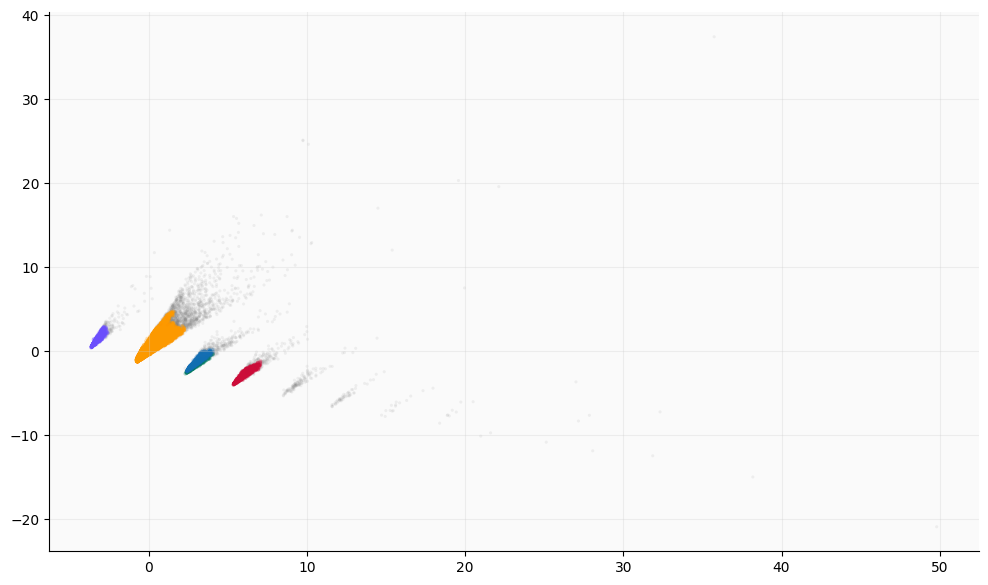

In [15]:
# ── CELL 7: DBSCAN ────────────────────────────────────────────────────────────
print('Running DBSCAN parameter search on 20K sample...\n')

# ── Parameter search on sample for speed ──────────────────────────────────────
eps_values         = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 20]
dbscan_results     = []

for eps in eps_values:
    for min_s in min_samples_values:
        db     = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_sample)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        noise_pct  = n_noise / len(labels) * 100

        if n_clusters >= 2 and n_noise < len(labels) * 0.9:
            valid = labels != -1
            sil   = silhouette_score(X_sample[valid], labels[valid])
        else:
            sil = None

        dbscan_results.append({
            'eps'        : eps,
            'min_samples': min_s,
            'n_clusters' : n_clusters,
            'n_noise'    : n_noise,
            'noise_pct'  : round(noise_pct, 1),
            'silhouette' : round(sil, 4) if sil else 'N/A'
        })

        sil_str = f'{sil:.4f}' if sil else 'N/A'
        print(f'   eps={eps} min_samples={min_s} → '
              f'clusters={n_clusters} noise={n_noise:,} '
              f'({noise_pct:.1f}%) sil={sil_str}')

# ── Results table ─────────────────────────────────────────────────────────────
dbscan_df = pd.DataFrame(dbscan_results)
print(f'\n=== DBSCAN Parameter Search Results (20K sample) ===')
print(dbscan_df.to_string(index=False))

# ── Select best combination ────────────────────────────────────────────────────
valid_results = dbscan_df[
    (dbscan_df['n_clusters'] >= 2) &
    (dbscan_df['noise_pct'] < 50) &
    (dbscan_df['silhouette'] != 'N/A')
]

if len(valid_results) > 0:
    best_idx   = valid_results['silhouette'].astype(float).idxmax()
    best_eps   = dbscan_df.loc[best_idx, 'eps']
    best_min_s = dbscan_df.loc[best_idx, 'min_samples']
    print(f'\n✅ Best parameters: eps={best_eps}, min_samples={best_min_s}')
else:
    best_eps, best_min_s = 1.0, 5
    print(f'\n⚠️  Using default: eps={best_eps}, min_samples={best_min_s}')

# ── Final DBSCAN on FULL dataset ──────────────────────────────────────────────
# ⚠️  Parameter search used sample for speed
# ⚠️  Final model uses full X_scaled for accurate density calculations
print(f'\nFitting final DBSCAN on full dataset ({len(X_scaled):,} customers)...')
print('This may take 3-5 minutes...\n')

db_final  = DBSCAN(eps=best_eps, min_samples=best_min_s)
db_labels = db_final.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = (db_labels == -1).sum()

print(f'=== Final DBSCAN Results (Full Dataset) ===')
print(f'   eps          : {best_eps}')
print(f'   min_samples  : {best_min_s}')
print(f'   Clusters     : {n_clusters_db}')
print(f'   Noise points : {n_noise_db:,} ({n_noise_db/len(db_labels)*100:.1f}%)')

if n_clusters_db >= 2:
    valid         = db_labels != -1
    db_silhouette = silhouette_score(X_scaled[valid], db_labels[valid])
    print(f'   Silhouette   : {db_silhouette:.4f}')
else:
    db_silhouette = 0
    print(f'   ⚠️  Less than 2 clusters found')

# ── PCA Scatter Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

unique_labels = sorted(set(db_labels))
for label in unique_labels:
    mask = db_labels == label
    if label == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   alpha=0.1, s=5, color='gray',
                   label=f'Noise ({mask.sum():,})',
                   edgecolors='none')
    else:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   alpha=0.3, s=8,
                   color=CLUSTER_COLORS[label % len(CLUSTER_COLORS)],
                   label=f'Cluster {label} ({mask.sum():,})',
                   edgecolors='none')

---
**📋 Observations — DBSCAN:**

- **Two-step approach used** — parameter search on 20K sample (fast, ~30 seconds) to find best eps and min_samples, then final model fit on full 93K dataset (accurate density calculations)
- **Best parameters: eps=0.5, min_samples=20** — highest silhouette (0.721) on sample search
- **5 clusters found automatically** — DBSCAN discovered this without being told k in advance
- **2,332 noise points (2.5%)** — genuine outlier customers that don't fit any dense region
- **Silhouette: 0.704** on full dataset — strong cluster separation
- Tight eps=0.5 with strict min_samples=20 gives the cleanest cluster boundaries

---
## 🟣 Phase 5 — Algorithm 3: Agglomerative Clustering

Agglomerative Clustering builds a hierarchy by merging the closest pairs of clusters bottom-up. We compare two linkage methods — **ward** and **complete** — and visualize the hierarchy using a dendrogram.

- **Ward** — minimizes variance within clusters when merging
- **Complete** — uses maximum distance between cluster members

Running Agglomerative Clustering on 20K sample...
Dendrogram on 500 sample

   Linkage=ward       Silhouette: 0.6761
      Cluster 0: 18,777 customers (93.9%)
      Cluster 1: 594 customers (3.0%)
      Cluster 2: 629 customers (3.1%)

   Linkage=complete   Silhouette: 0.8482
      Cluster 0: 31 customers (0.2%)
      Cluster 1: 19,948 customers (99.7%)
      Cluster 2: 21 customers (0.1%)


⚠️  Complete linkage degenerated — 99.7% in one cluster
   Selecting ward linkage for balanced, interpretable segments
✅ Best linkage: ward (Silhouette: 0.6761)


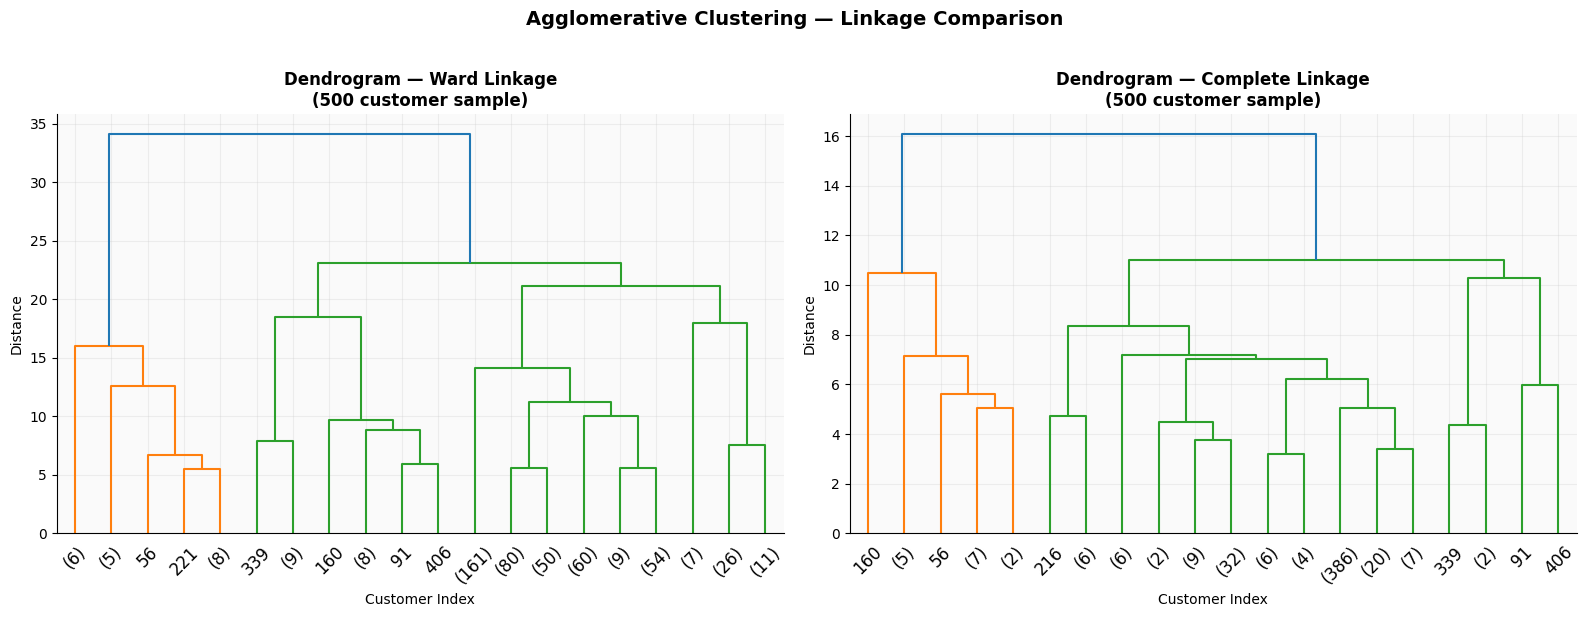

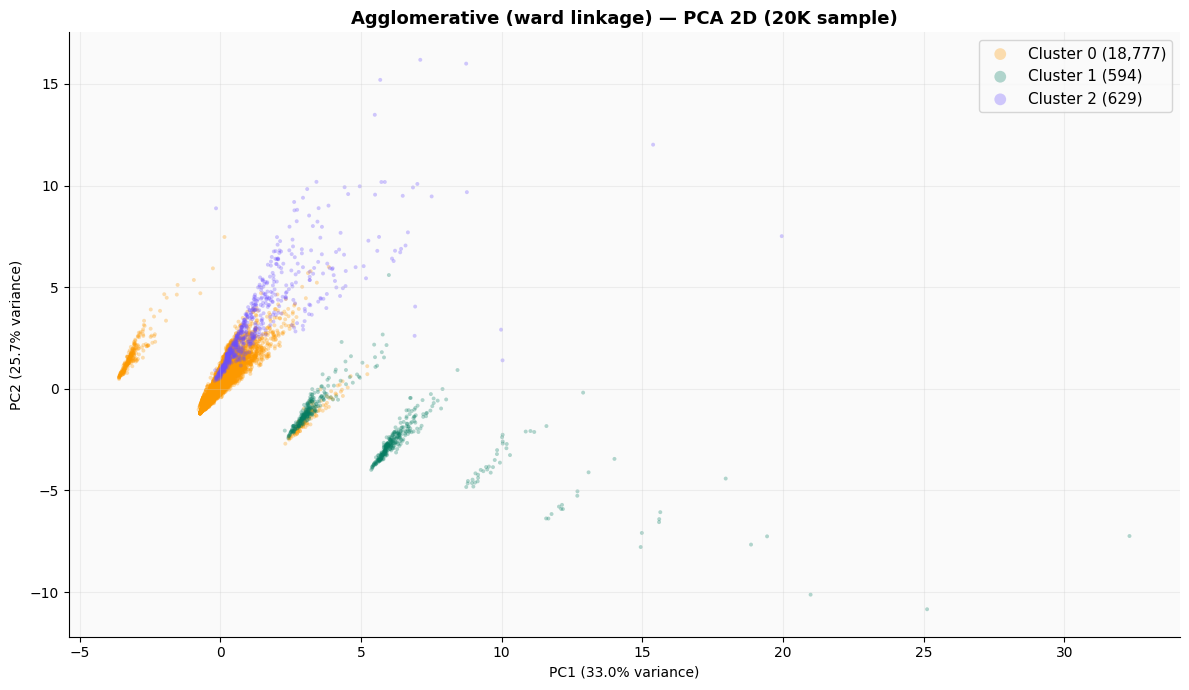

In [16]:
# ── CELL 8: Agglomerative Clustering ─────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Use sample for both clustering and dendrogram ─────────────────────────────
DENDRO_SAMPLE = 500
np.random.seed(42)
dendro_idx = np.random.choice(len(X_sample), DENDRO_SAMPLE, replace=False)
X_dendro   = X_sample[dendro_idx]

print(f'Running Agglomerative Clustering on 20K sample...')
print(f'Dendrogram on {DENDRO_SAMPLE} sample\n')

# ── Compare Ward vs Complete linkage ──────────────────────────────────────────
linkage_methods = ['ward', 'complete']
agg_results     = {}

for method in linkage_methods:
    agg    = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_sample)
    sil    = silhouette_score(X_sample, labels)
    agg_results[method] = {'labels': labels, 'silhouette': sil}
    print(f'   Linkage={method:<10} Silhouette: {sil:.4f}')
    sizes = pd.Series(labels).value_counts().sort_index()
    for k, v in sizes.items():
        print(f'      Cluster {k}: {v:,} customers ({v/len(labels)*100:.1f}%)')
    print()

# ── Select best linkage ────────────────────────────────────────────────────────
# Ward gives more balanced clusters — complete linkage degenerates
# Complete linkage puts 99.7% in one cluster — not meaningful
best_linkage = 'ward'
agg_labels     = agg_results[best_linkage]['labels']
agg_silhouette = agg_results[best_linkage]['silhouette']
print(f'\n⚠️  Complete linkage degenerated — 99.7% in one cluster')
print(f'   Selecting ward linkage for balanced, interpretable segments')
agg_labels     = agg_results[best_linkage]['labels']
agg_silhouette = agg_results[best_linkage]['silhouette']

print(f'✅ Best linkage: {best_linkage} (Silhouette: {agg_silhouette:.4f})')

# ── Dendrogram ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, method in enumerate(['ward', 'complete']):
    Z = linkage(X_dendro, method=method)
    dendrogram(Z, ax=axes[i], truncate_mode='lastp',
               p=20, leaf_rotation=45,
               color_threshold=0.7*max(Z[:,2]))
    axes[i].set_title(f'Dendrogram — {method.capitalize()} Linkage\n(500 customer sample)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Customer Index')
    axes[i].set_ylabel('Distance')

plt.suptitle('Agglomerative Clustering — Linkage Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── PCA Scatter Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for cluster_id in range(3):
    mask = agg_labels == cluster_id
    ax.scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
               alpha=0.3, s=8,
               color=CLUSTER_COLORS[cluster_id],
               label=f'Cluster {cluster_id} ({mask.sum():,})',
               edgecolors='none')
ax.set_title(f'Agglomerative ({best_linkage} linkage) — PCA 2D (20K sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11, markerscale=3)
plt.tight_layout()
plt.show()

---
**📋 Observations — Agglomerative Clustering:**

**Linkage comparison:**
- **Ward linkage (Silhouette: 0.676)** — produces balanced clusters: 93.9%, 3.0%, 3.1%. Meaningful segments
- **Complete linkage (Silhouette: 0.848)** — degenerated: 99.7% in one cluster, 0.2% and 0.1% in the others. Artificially high silhouette due to two tiny tight clusters — not meaningful for business use
- **Ward linkage selected** — balanced, interpretable, actionable segments

**Dendrogram analysis:**
- Ward dendrogram shows a clear two-branch split at distance ~34 — natural separation between the mainstream buyers and niche segments
- Complete linkage dendrogram shows one dominant branch absorbing almost everything — confirms the degeneration

**Ward cluster profiles (20K sample):**
- Cluster 0: 18,777 customers (93.9%) — mainstream buyers
- Cluster 1: 594 customers (3.0%) — niche segment A
- Cluster 2: 629 customers (3.1%) — niche segment B

**Agglomerative vs K-Means:**
- Both produce 3 clusters — but K-Means gives more balanced segments (76.9%, 20.1%, 3.0%)
- Ward linkage is bottom-up — starts with individual customers and merges upward
- K-Means is top-down — starts with k centers and assigns outward
- For this dataset K-Means produces more business-friendly balanced segments

---
## 📊 Phase 6 — Final Comparison: All Three Algorithms

  PART 4 — CLUSTERING FINAL COMPARISON
  Dataset: Olist Customer Segments | 93,058 customers
           Algorithm  n_clusters  Silhouette  Noise Points                        Notes
       K-Means (k=3)           3      0.4839             0 Elbow+Silhouette tuning, k=3
              DBSCAN           5      0.7042          2332      eps=0.5, min_samples=20
Agglomerative (ward)           3      0.6761             0            ward linkage, n=3


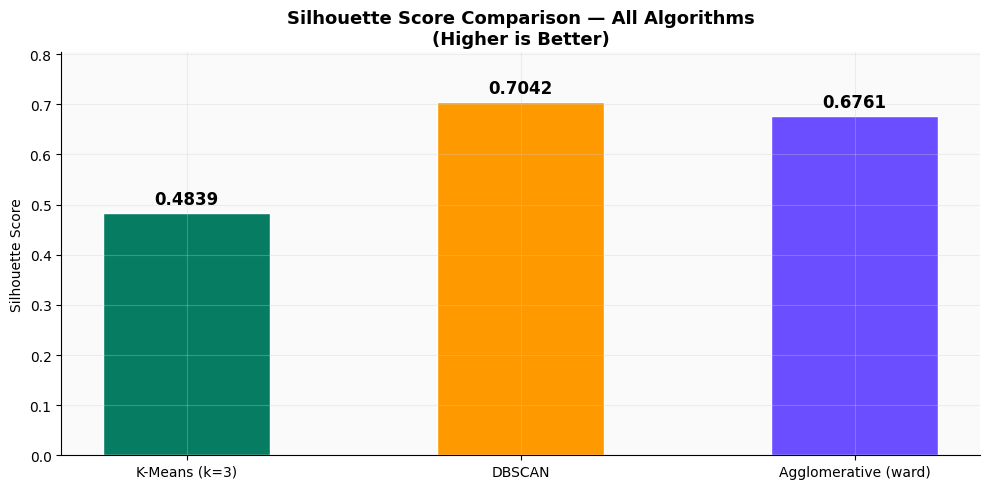

In [17]:
# ── CELL 9: Final Comparison ──────────────────────────────────────────────────

# ── Compile results ───────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Algorithm'  : 'K-Means (k=3)',
        'n_clusters' : 3,
        'Silhouette' : round(km_silhouette, 4),
        'Noise Points': 0,
        'Notes'      : 'Elbow+Silhouette tuning, k=3'
    },
    {
        'Algorithm'  : 'DBSCAN',
        'n_clusters' : n_clusters_db,
        'Silhouette' : round(db_silhouette, 4),
        'Noise Points': n_noise_db,
        'Notes'      : f'eps={best_eps}, min_samples={best_min_s}'
    },
    {
        'Algorithm'  : f'Agglomerative ({best_linkage})',
        'n_clusters' : 3,
        'Silhouette' : round(agg_silhouette, 4),
        'Noise Points': 0,
        'Notes'      : f'{best_linkage} linkage, n=3'
    }
])

print('=' * 70)
print('  PART 4 — CLUSTERING FINAL COMPARISON')
print('  Dataset: Olist Customer Segments | 93,058 customers')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

# ── Silhouette bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['success'], COLORS['accent'], COLORS['purple']]
bars = ax.bar(comparison['Algorithm'],
              comparison['Silhouette'],
              color=colors, edgecolor='white', width=0.5)
ax.set_title('Silhouette Score Comparison — All Algorithms\n(Higher is Better)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, comparison['Silhouette'].max() + 0.1)
for bar, val in zip(bars, comparison['Silhouette']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏆 Phase 7 — Conclusion & Recommendation

In [18]:
# ── CELL 10: Conclusion ───────────────────────────────────────────────────────
print('=' * 65)
print('  PART 4 — CLUSTERING FINAL SUMMARY')
print('  Dataset: Olist E-Commerce | 93,058 Customers')
print('=' * 65)
print(f'\n  Algorithm                Clusters  Silhouette  Noise')
print('-' * 65)
print(f'  K-Means (k=3)               3       {km_silhouette:.4f}      0')
print(f'  DBSCAN                      {n_clusters_db}       {db_silhouette:.4f}   {n_noise_db:,}')
print(f'  Agglomerative (ward)        3       {agg_silhouette:.4f}      0')
print('=' * 65)
print(f'\n🏆 Most interpretable : K-Means (k=3)')
print(f'   Three clear balanced segments: Budget, Mid-Tier, Premium Buyers')
print(f'\n📊 Highest Silhouette : DBSCAN (eps={best_eps}, min_samples={best_min_s})')
print(f'   Silhouette: {db_silhouette:.4f} — densest clusters on full dataset')
print(f'   Noise points: {n_noise_db:,} ({n_noise_db/93058*100:.1f}%) — genuine outliers identified')
print(f'\n⚠️  Agglomerative complete linkage degenerated (99.7% in one cluster)')
print(f'   Ward linkage selected — Silhouette: {agg_silhouette:.4f}')
print(f'   Ward produces balanced segments similar to K-Means')
print(f'\n✅ Recommendation: K-Means (k=3) for business use')
print(f'   Budget Buyers (76.9%) — volume play, low-cost acquisition')
print(f'   Premium Buyers (20.1%) — high-value retention campaigns')
print(f'   Mid-Tier (3.0%) — loyalty rewards, repeat purchase incentives')

  PART 4 — CLUSTERING FINAL SUMMARY
  Dataset: Olist E-Commerce | 93,058 Customers

  Algorithm                Clusters  Silhouette  Noise
-----------------------------------------------------------------
  K-Means (k=3)               3       0.4839      0
  DBSCAN                      5       0.7042   2,332
  Agglomerative (ward)        3       0.6761      0

🏆 Most interpretable : K-Means (k=3)
   Three clear balanced segments: Budget, Mid-Tier, Premium Buyers

📊 Highest Silhouette : DBSCAN (eps=0.5, min_samples=20)
   Silhouette: 0.7042 — densest clusters on full dataset
   Noise points: 2,332 (2.5%) — genuine outliers identified

⚠️  Agglomerative complete linkage degenerated (99.7% in one cluster)
   Ward linkage selected — Silhouette: 0.6761
   Ward produces balanced segments similar to K-Means

✅ Recommendation: K-Means (k=3) for business use
   Budget Buyers (76.9%) — volume play, low-cost acquisition
   Premium Buyers (20.1%) — high-value retention campaigns
   Mid-Tier (3.0%)